# 01 GSE238110 expression QC and normalization

Purpose: inspect canine osteosarcoma raw counts, preserve raw data, create clean counts and log2-CPM matrices.

In [1]:
from pathlib import Path
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("Project root:", PROJECT_ROOT)
print("Raw data dir:", RAW_DIR)
print("Processed data dir:", PROCESSED_DIR)

Project root: C:\Users\olegk\Desktop\paper4_sarcoma_dog
Raw data dir: C:\Users\olegk\Desktop\paper4_sarcoma_dog\data\raw
Processed data dir: C:\Users\olegk\Desktop\paper4_sarcoma_dog\data\processed


In [2]:
def find_file(folder, patterns):
    folder = Path(folder)
    hits = []
    for pattern in patterns:
        hits.extend(folder.glob(pattern))
    hits = sorted(set(hits))
    if not hits:
        raise FileNotFoundError(f"No matching files in {folder}. Patterns: {patterns}")
    if len(hits) > 1:
        print("Multiple candidates found:")
        for p in hits:
            print(" ", p.name)
        print("Using:", hits[0].name)
    return hits[0]

expr_path = find_file(
    RAW_DIR / "canine_discovery_GSE238110",
    ["*RawCountFile*combined*.csv", "*RawCountFile*combined*.csv.gz", "*.csv", "*.csv.gz"]
)

print("Expression file:", expr_path)
counts_raw = pd.read_csv(expr_path, compression="infer")
print("Raw shape:", counts_raw.shape)
display(counts_raw.head())
display(pd.DataFrame({"column": counts_raw.columns[:20]}))

Expression file: C:\Users\olegk\Desktop\paper4_sarcoma_dog\data\raw\canine_discovery_GSE238110\GSE238110_RawCountFile_combined.csv
Raw shape: (37952, 199)


,gene_id,14_0614__Tumor,5_0220__Tumor,13_0613__Tumor,26_0722__Tumor,4_0214__Tumor,10_0512__Tumor,32_0904__Tumor,49_1803__Tumor,9_0510__Tumor,18_0620_Me_T__Skin,16_0616__Tumor,19_0621__Tumor,2_0209__Tumor,37_1015__Tumor,8_0335__Tumor,21_0631__Tumor,52_2006__Tumor,48_1712__Tumor,46_1703__Tumor,36_1014__Tumor,11_0602__Tumor,41_1407__Tumor,1_0202_tumor,25_0706__Tumor,7_0309__Tumor,35_1007__Tumor,27_0723__Tumor,22_0640__Tumor,33_1002__Tumor,45_1701__Tumor,28_0725__Tumor,20_0621_Me_T__Unspecified,54_2303__Tumor,53_2011__Tumor,43_1410__Tumor,55_2308__Tumor,51_1902__Tumor,24_0704__Tumor,17_0620__Tumor,39_1103__Tumor,50_1805__Tumor,15_0615__Tumor,12_0608__Tumor,47_1709__Tumor,6_0305__Tumor,40_1107__Tumor,34_1004__Tumor,38_1016__Tumor,31_0902__Tumor,30_0814_RNAla_Ter__tumor,3_0212__Tumor,29_0729__Tumor,44_1412__Tumor,23_0642__Tumor,42_1409__Tumor,117_1011_tumor,131_2012_tumor,48_0705_tumor,90_0224_tumor,...,129_1414_tumor,45_1024_tumor,58_1104_tumor,115_2318_tumor,137_0106_tumor,59_1003_tumor,4_0215_Tumor,60_1415_tumor,140_0905_tumor,6_1012_Tumor,33_0524_tumor,114_1704_tumor,37_0625_tumor,89_0216_tumor,26_0509_tumor,64_1009_tumor,75_0819_tumor,88_0712_tumor,108_0720_tumor,41_2007_tumor,132_1025_tumor,92_0404_tumor,39_0701_tumor,139_0733_tumor,123_2316_tumor,100_0514_tumor,18_0301_tumor,11_0310_Met_rib,54_1013_tumor,53_0717_tumor,19_0303_tumor,44_0713_tumor,106_0716_tumor,40_1101_tumor,21_0311_tumor,12_0327_Met_lung,20_0307_tumor,25_0505_tumor,34_0601_tumor,77_1417_tumor,76_1106_tumor,55_2307_tumor,116_0506_tumor,63_1411_tumor,36_0607_tumor,29_0515_tumor,124_1702_tumor,125_2004_tumor,135_0102_tumor,136_0105_tumor,1_0201_tumor,128_1023_tumor,109_0721_tumor,10_0227_Met_spinal,142_1710_tumor,56_1001_tumor,68_0210_tumor,102_0619_tumor,52_2317_tumor,118_2304_tumor
0,A1BG_3,0.0,1.0,0.0,0.0,7.0,3.0,3.0,0.0,1.0,1.0,0.0,8.0,3.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,3.0,5.0,4.0,4.0,4.0,2.0,0.0,0.0,1.0,1.0,2.0,1.0,2.0,4.0,1.0,1.0,0.0,3.0,1.0,1.0,2.0,12.0,1.0,0.0,5.0,0.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,5.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,3.0,8.0,5.0,1.0,0.0,5.0,0.0,2.0,0.0,1.0,2.0,3.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
1,A1CF_3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
2,A2ML1_3,1.0,0.0,0.0,1.0,6.0,0.0,17.0,0.0,0.0,1.0,0.0,16.0,7.0,0.0,2.0,3.0,2.0,9.0,4.0,5.0,4.0,0.0,8.0,2.0,2.0,15.0,42.0,60.0,3.0,0.0,3.0,0.0,0.0,20.0,53.0,1.0,0.0,5.0,1.0,0.0,1.0,1.0,1.0,1.0,11.0,2.0,3.0,1.0,4.0,3.0,34.0,14.0,0.0,39.0,2.0,0.0,1.0,25.0,4.0,...,0.0,1.0,12.0,0.0,0.0,3.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,8.0,10.0,37.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0,27.0,19.0,0.0,1.0,3.0,3.0,0.0,1.0,3.0,0.0,8.0,0.0,1.0,2.0,0.0,177.0,1.0,0.0,0.0,73.0,0.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,182.0
3,A3GALT2_3,47.0,1.0,0.0,5.0,0.0,0.0,8.0,6.0,2.0,11.0,0.0,1.0,5.0,11.0,2.0,4.0,7.0,7.0,2.0,6.0,6.0,2.0,6.0,2.0,0.0,3.0,8.0,25.0,8.0,11.0,16.0,3.0,1.0,15.0,6.0,7.0,1.0,3.0,1.0,7.0,2.0,3.0,0.0,1.0,2.0,134.0,49.0,2.0,5.0,4.0,38.0,231.0,1.0,8.0,5.0,0.0,0.0,1.0,3.0,...,1.0,1.0,0.0,4.0,11.0,2.0,1.0,4.0,2.0,2.0,36.0,2.0,3.0,2.0,2.0,2.0,6.0,5.0,2.0,0.0,0.0,3.0,0.0,3.0,2.0,4.0,86.0,1.0,2.0,10.0,0.0,6.0,0.0,5.0,0.0,45.0,2.0,4.0,22.0,25.0,0.0,0.0,0.0,3.0,0.0,1.0,4.0,0.0,3.0,4.0,1.0,0.0,20.0,2.0,1.0,0.0,0.0,2.0,0.0,1.0
4,A4GALT_3,327.0,13.0,47.0,68.0,33.0,96.0,95.0,365.0,308.0,375.0,122.0,25.0,67.0,92.0,1013.0,68.0,412.0,293.0,57.0,37.0,254.0,608.0,366.0,196.0,18.0,50.0,84.0,71.0,17.0,205.0,133.0,93.0,911.0,188.0,159.0,1243.0,237.0,

,column
0,gene_id
1,14_0614__Tumor
2,5_0220__Tumor
3,13_0613__Tumor
4,26_0722__Tumor
5,4_0214__Tumor
6,10_0512__Tumor
7,32_0904__Tumor
8,49_1803__Tumor
9,9_0510__Tumor


In [3]:
gene_col = counts_raw.columns[0]
counts = counts_raw.copy()

print("Gene column:", gene_col)
print("Duplicate gene IDs:", counts[gene_col].duplicated().sum())
print("Missing gene IDs:", counts[gene_col].isna().sum())

counts[gene_col] = counts[gene_col].astype(str).str.strip()
counts = counts.dropna(subset=[gene_col])

numeric = counts.drop(columns=[gene_col]).apply(pd.to_numeric, errors="coerce")
numeric.index = counts[gene_col]

dup_genes = numeric.index.duplicated().sum()
if dup_genes > 0:
    numeric = numeric.groupby(level=0).sum()

all_zero_genes = (numeric.sum(axis=1) == 0).sum()
counts_clean = numeric.loc[numeric.sum(axis=1) > 0].copy()

print("Matrix shape before removing all-zero genes:", numeric.shape)
print("All-zero genes removed:", int(all_zero_genes))
print("Clean counts shape:", counts_clean.shape)
display(counts_clean.iloc[:5, :5])

Gene column: gene_id
Duplicate gene IDs: 0
Missing gene IDs: 0
Matrix shape before removing all-zero genes: (37952, 198)
All-zero genes removed: 7600
Clean counts shape: (30352, 198)


,14_0614__Tumor,5_0220__Tumor,13_0613__Tumor,26_0722__Tumor,4_0214__Tumor
gene_id,,,,,
A1BG_3,0.0,1.0,0.0,0.0,7.0
A1CF_3,0.0,0.0,0.0,0.0,0.0
A2ML1_3,1.0,0.0,0.0,1.0,6.0
A3GALT2_3,47.0,1.0,0.0,5.0,0.0
A4GALT_3,327.0,13.0,47.0,68.0,33.0


In [4]:
def extract_bracket_id(x):
    x = str(x)
    m = re.search(r"\[([^\]]+)\]", x)
    return m.group(1).strip() if m else x.strip()

sample_map = pd.DataFrame({
    "original_sample_column": counts_clean.columns,
    "sample_id_bracket": [extract_bracket_id(c) for c in counts_clean.columns],
})

print("Samples:", sample_map.shape[0])
display(sample_map.head(20))
sample_map.to_csv(PROCESSED_DIR / "GSE238110_sample_id_map.csv", index=False)

Samples: 198


,original_sample_column,sample_id_bracket
0,14_0614__Tumor,14_0614__Tumor
1,5_0220__Tumor,5_0220__Tumor
2,13_0613__Tumor,13_0613__Tumor
3,26_0722__Tumor,26_0722__Tumor
4,4_0214__Tumor,4_0214__Tumor
5,10_0512__Tumor,10_0512__Tumor
6,32_0904__Tumor,32_0904__Tumor
7,49_1803__Tumor,49_1803__Tumor
8,9_0510__Tumor,9_0510__Tumor
9,18_0620_Me_T__Skin,18_0620_Me_T__Skin


,library_size,detected_genes
count,1.980000e+02,198.000000
mean,1.277709e+07,18296.439394
std,4.744481e+06,936.188099
min,6.587634e+06,16473.000000
25%,9.197988e+06,17584.500000
50%,1.084835e+07,18212.500000
75%,1.725778e+07,18894.500000
max,2.742087e+07,21113.000000


,library_size,detected_genes
sample_column,,
68_0210_tumor,6587634.08,16703
128_1023_tumor,6715160.96,16900
143_1916_tumor,6791149.11,16844
3_0207_Tumor,7038011.03,17566
113_1010_tumor,7193809.99,17489
72_0732_tumor,7285217.05,18310
2_0203_Tumor,7423496.02,18246
8_2202_Tumor,7446127.06,17475
23_0329_tumor,7499832.93,17147


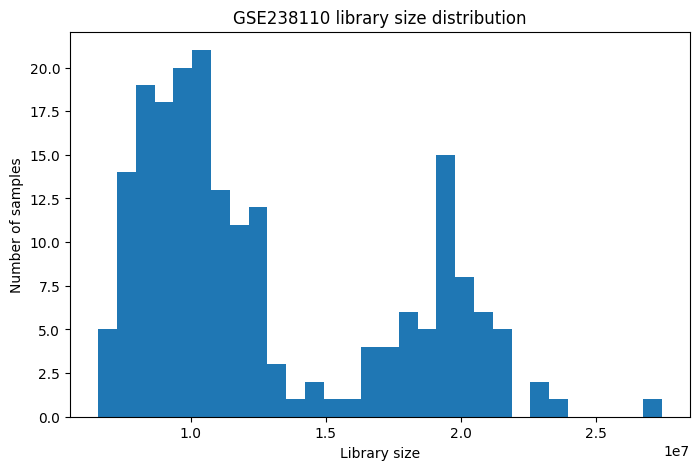

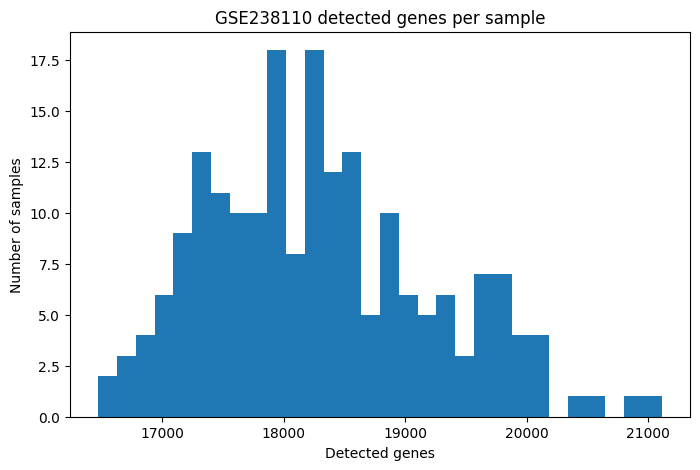

In [5]:
library_size = counts_clean.sum(axis=0).sort_values()
detected_genes = (counts_clean > 0).sum(axis=0).sort_values()

qc_samples = pd.DataFrame({
    "library_size": library_size,
    "detected_genes": detected_genes.reindex(library_size.index),
})
qc_samples.index.name = "sample_column"

display(qc_samples.describe())
display(qc_samples.head(10))

plt.figure(figsize=(8, 5))
plt.hist(qc_samples["library_size"], bins=30)
plt.xlabel("Library size")
plt.ylabel("Number of samples")
plt.title("GSE238110 library size distribution")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(qc_samples["detected_genes"], bins=30)
plt.xlabel("Detected genes")
plt.ylabel("Number of samples")
plt.title("GSE238110 detected genes per sample")
plt.show()

,detection_fraction,total_counts
count,30352.000000,3.035200e+04
mean,0.602808,8.335079e+04
std,0.420635,7.380220e+05
min,0.005051,6.000000e-02
25%,0.106061,4.500000e+01
50%,0.818182,1.757500e+03
75%,1.000000,5.638809e+04
max,1.000000,7.073692e+07


,detection_fraction,total_counts
gene_id,,
ZNRF4_3,0.005051,5.0
LOC111092826_2,0.005051,1.0
C2H16orf78_3,0.005051,2.0
LOC119869809_3,0.005051,1.0
LOC111092891_3,0.005051,3.0
LOC111092899_3,0.005051,1.0
LOC111092900_3,0.005051,1.0
LOC102154332_1,0.005051,1.0
LOC119869918_3,0.005051,2.0


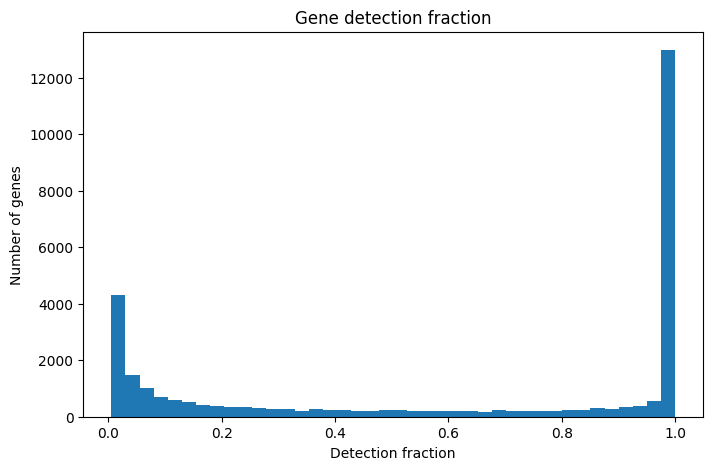

In [6]:
gene_detection_fraction = (counts_clean > 0).mean(axis=1)
gene_total_counts = counts_clean.sum(axis=1)

gene_qc = pd.DataFrame({
    "detection_fraction": gene_detection_fraction,
    "total_counts": gene_total_counts,
})
gene_qc.index.name = "gene_id"

display(gene_qc.describe())
display(gene_qc.sort_values("detection_fraction").head(10))

plt.figure(figsize=(8, 5))
plt.hist(gene_qc["detection_fraction"], bins=40)
plt.xlabel("Detection fraction")
plt.ylabel("Number of genes")
plt.title("Gene detection fraction")
plt.show()

Filtered counts shape: (21016, 198)
log2-CPM shape: (21016, 198)


,14_0614__Tumor,5_0220__Tumor,13_0613__Tumor,26_0722__Tumor,4_0214__Tumor
gene_id,,,,,
A1BG_3,0.000000,0.084511,0.000000,0.000000,0.512624
A2ML1_3,0.073920,0.000000,0.000000,0.077877,0.449634
A3GALT2_3,1.795312,0.084511,0.000000,0.353118,0.000000
A4GALT_3,4.185168,0.835335,1.738246,2.254452,1.590395
A4GNT_3,0.000000,0.000000,0.136738,0.000000,0.000000


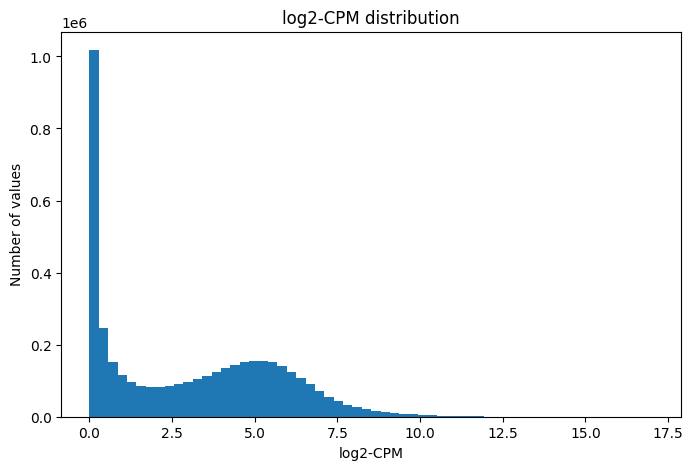

In [7]:
min_detection_fraction = 0.20
counts_filtered = counts_clean.loc[gene_detection_fraction >= min_detection_fraction].copy()

library_size_filtered = counts_filtered.sum(axis=0)
cpm = counts_filtered.div(library_size_filtered, axis=1) * 1_000_000
log2_cpm = np.log2(cpm + 1)

print("Filtered counts shape:", counts_filtered.shape)
print("log2-CPM shape:", log2_cpm.shape)

display(log2_cpm.iloc[:5, :5])

plt.figure(figsize=(8, 5))
plt.hist(log2_cpm.to_numpy().ravel(), bins=60)
plt.xlabel("log2-CPM")
plt.ylabel("Number of values")
plt.title("log2-CPM distribution")
plt.show()

In [8]:
counts_clean.to_csv(PROCESSED_DIR / "GSE238110_counts_clean.csv")
counts_filtered.to_csv(PROCESSED_DIR / "GSE238110_counts_filtered_detection20.csv")
log2_cpm.to_csv(PROCESSED_DIR / "GSE238110_log2cpm_detection20.csv")
gene_qc.to_csv(PROCESSED_DIR / "GSE238110_gene_qc.csv")
qc_samples.to_csv(PROCESSED_DIR / "GSE238110_sample_qc.csv")

summary = {
    "raw_shape": list(counts_raw.shape),
    "clean_counts_shape": list(counts_clean.shape),
    "filtered_counts_shape": list(counts_filtered.shape),
    "n_samples": int(counts_clean.shape[1]),
    "min_detection_fraction": float(min_detection_fraction),
}
with open(PROCESSED_DIR / "GSE238110_expression_qc_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

summary

{'raw_shape': [37952, 199],
 'clean_counts_shape': [30352, 198],
 'filtered_counts_shape': [21016, 198],
 'n_samples': 198,
 'min_detection_fraction': 0.2}